### Import Necessary Libraries

In [ ]:
import pandas as pd # Data manipulation and analysis
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # Statistical data visualization

### Loading the Dataset

In [ ]:
pd.set_option('display.max_columns', None) # Display all columns in the DataFrame
df = pd.read_csv('NYC.csv', encoding='latin-1') # Load the dataset
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### Data Understanding 

In [ ]:
df.describe() # Get summary statistics of the dataset

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [ ]:
df.info() # Get information about the dataset, including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [ ]:
df.isnull().sum() # Check for missing values in each column

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [ ]:
df.duplicated().sum() # Check for duplicate rows in the dataset

0

In [ ]:
df.shape # Get the number of rows and columns in the dataset

(1458644, 11)

In [ ]:
df.size # Get the total number of elements in the dataset

16045084

In [ ]:
df['store_and_fwd_flag'].value_counts() # Analyze the distribution of the 'store_and_fwd_flag' column to understand how many trips were stored and forwarded versus not.

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

### Data Structuring

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime']) # Convert 'pickup_datetime' to datetime format for easier analysis of hourly and daily patterns
df.dtypes # Check the data types of each column in the dataset  

id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime              object
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

In [ ]:
df['trip_duration_in_minutes'] = df['trip_duration'] / 60 # Convert trip duration from seconds to minutes for better interpretability

In [ ]:
df.drop(columns=['id','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude'], inplace=True) # Drop columns that are not relevant for the analysis of hourly and daily patterns, such as 'id' and location coordinates.

In [15]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,store_and_fwd_flag,trip_duration,trip_duration_in_minutes
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,N,455,7.583333
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,N,663,11.050000
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,N,2124,35.400000
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,N,429,7.150000
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,N,435,7.250000


#### Outliers Filtering

In [ ]:
outliers = df[(df['trip_duration_in_minutes'] < 1) | (df['trip_duration_in_minutes'] > 120)] # Identify outliers in trip duration, considering trips that are less than 1 minute or greater than 120 minutes as outliers
outliers.head()


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,store_and_fwd_flag,trip_duration,trip_duration_in_minutes
72,2,2016-02-20 21:58:13,2016-02-20 21:59:10,1,N,57,0.950000
323,1,2016-06-27 11:22:37,2016-06-27 11:23:17,1,N,40,0.666667
531,2,2016-02-20 04:03:06,2016-02-21 03:33:00,3,N,84594,1409.900000
842,2,2016-05-21 12:46:46,2016-05-21 12:46:49,2,N,3,0.050000
853,2,2016-03-29 22:39:46,2016-03-29 22:40:44,5,N,58,0.966667


In [ ]:
outliers.shape # Get the number of outliers identified in the dataset

(10848, 7)

In [18]:
df = df[~df.index.isin(outliers.index)] # Remove outliers from the original DataFrame
df.shape # Check the shape of the DataFrame after removing outliers

(1447796, 7)

In [ ]:
new_df = df.copy() # Create a copy of the cleaned DataFrame for further analysis
new_df.drop(columns=['trip_duration','store_and_fwd_flag'], inplace=True) # Drop columns that are not needed for the analysis of hourly and daily patterns, such as 'trip_duration' (since we have 'trip_duration_in_minutes') and 'store_and_fwd_flag' (since it is not relevant for pattern analysis).

In [ ]:
new_df['hour_of_day'] = new_df['pickup_datetime'].dt.hour # Extract the hour of the day from 'pickup_datetime' to analyze hourly patterns in taxi demand
new_df['day_of_week'] = new_df['pickup_datetime'].apply(lambda x: x.isoweekday()) # Extract the day of the week from 'pickup_datetime' to analyze daily patterns in taxi demand, where Monday=1 and Sunday=7
new_df['month_of_year'] = new_df['pickup_datetime'].dt.month # Extract the month of the year from 'pickup_datetime' to analyze monthly patterns in taxi demand
new_df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_duration_in_minutes,hour_of_day,day_of_week,month_of_year
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,7.583333,17,1,3
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,11.050000,0,7,6
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,35.400000,11,2,1
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,7.150000,19,3,4
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,7.250000,13,6,3


In [ ]:
peek_offpeek_hours= new_df.groupby('hour_of_day')['trip_duration_in_minutes'].count().reset_index( name='trip_count').set_index('hour_of_day')
peek_offpeek_hours= peek_offpeek_hours.sort_values(by='trip_count', ascending=False) # Sort the hours of the day based on the count of trips to identify peak and off-peak hours for taxi demand
peek_offpeek_hours

,trip_count
hour_of_day,
18,90022
19,89753
21,83607
20,83536
22,79936
17,75910
14,73697
12,71370
15,71223


In [ ]:
weekday_trips= new_df.groupby('day_of_week')['trip_duration_in_minutes'].count().reset_index(name='trip_count').set_index('day_of_week').sort_values(by='trip_count', ascending=False) # Group the data by day of the week and count the number of trips for each day, then sort the days based on trip count to identify which days have the highest and lowest taxi demand
weekday_trips = weekday_trips.sort_values(by='trip_count', ascending=False)
weekday_trips


,trip_count
day_of_week,
5,221870
6,219190
4,216947
3,208751
2,201318
7,193669
1,186051


In [ ]:
average_trip_duration_by_hour = new_df.groupby('hour_of_day')['trip_duration_in_minutes'].mean().reset_index(name='average_trip_duration').set_index('hour_of_day').sort_values(by='average_trip_duration', ascending=False) # Group the data by hour of the day and calculate the average trip duration for each hour, then sort the hours based on average trip duration to identify if there are any patterns in trip duration across different hours of the day
average_trip_duration_by_hour

,average_trip_duration
hour_of_day,
15,16.164062
16,16.158841
14,15.856380
17,15.595790
13,15.010536
12,14.696227
11,14.659226
18,14.398233
10,14.189638


In [ ]:
new_df.groupby('vendor_id').agg({'trip_duration_in_minutes': 'mean'}).reset_index().sort_values(by='trip_duration_in_minutes', ascending=False) # Analyze the average trip duration by vendor to see if there are differences in trip duration between different vendors.

,vendor_id,trip_duration_in_minutes
1,2,14.084657
0,1,13.933970


### Data Visualisations

#### *Line chart of trips by hour*

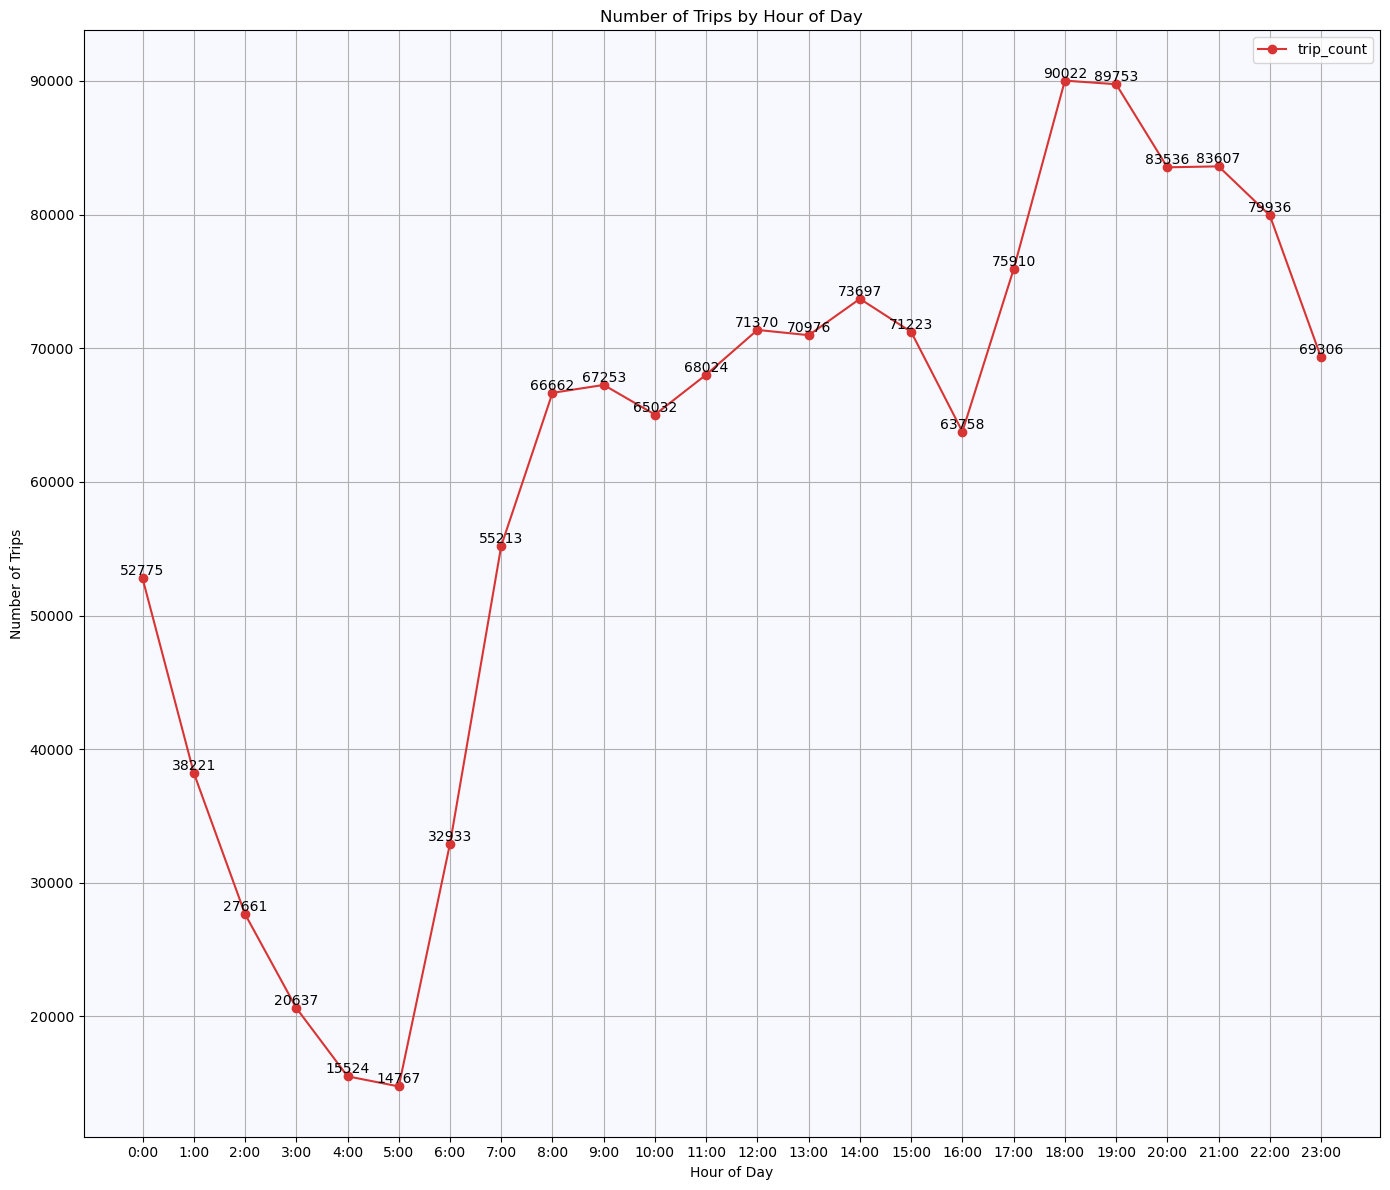

In [25]:
peek_offpeek_hours.sort_index(ascending= True).plot(kind='line',figsize = (14,12), marker='o', color="#D83434") # Plotting the line graph for number of trips by hour of day
for x in peek_offpeek_hours.index: # Adding data labels to each point on the line graph
    plt.text(x, peek_offpeek_hours.loc[x, 'trip_count'], str(peek_offpeek_hours.loc[x, 'trip_count']), ha='center', va='bottom')
plt.gca().set_facecolor('#F8F8FF') # Setting the background color of the graph to a light shade of gray (hex code #F8F8FF)
plt.title('Number of Trips by Hour of Day') # Setting the title of the graph to "Number of Trips by Hour of Day"
plt.xlabel('Hour of Day') # Setting x-axis label to "Hour of Day"
plt.ylabel('Number of Trips') # Setting y-axis label to "Number of Trips"
plt.xticks(range(0, 24), [f'{h}:00' for h in range(0, 24)]) # Setting x-axis ticks to show hours in 24-hour format
plt.tight_layout() # Adjust layout to prevent overlap
plt.grid() # Adding grid for better readability
plt.show()


#### *Bar chart of trips by weekday*

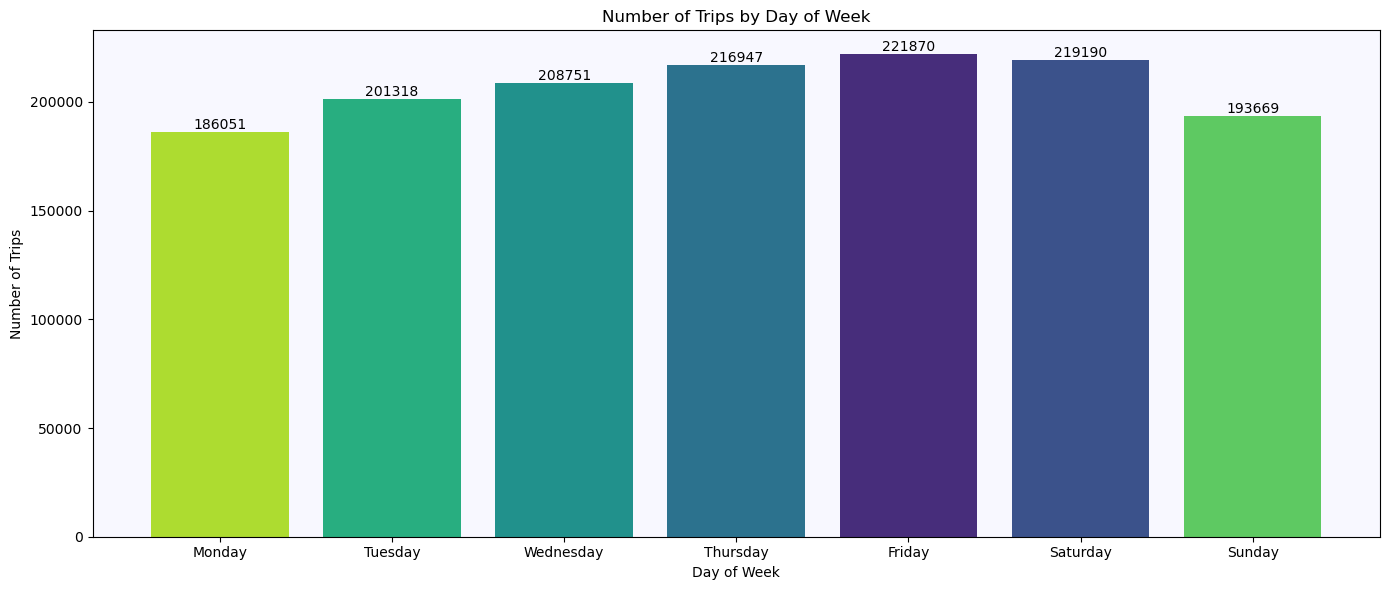

In [26]:
plt.figure(figsize=(14, 6)) # Set the figure size
ax = plt.gca() # Get the current axes
ax.bar(weekday_trips.index, weekday_trips['trip_count'], color= sns.color_palette('viridis',len(weekday_trips))) # Create a bar plot with a color palette
for x in ax.patches: # Add text labels on top of each bar
    plt.text(x.get_x() + x.get_width() / 2, x.get_height(), str(int(x.get_height())), ha='center', va='bottom')
ax.set_facecolor('#F8F8FF') # Set the background color of the plot
ax.set_title('Number of Trips by Day of Week') # Set the title of the plot
ax.set_xlabel('Day of Week') #  Set the x-axis label
ax.set_ylabel('Number of Trips') # Set the y-axis label
ax.set_xticks(range(1, 8)) # Set the x-ticks to correspond to the days of the week (1-7)
ax.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']) # Set the x-tick labels to the names of the days of the week

plt.tight_layout() # Adjust the layout to prevent overlap
plt.show()


#### *Histogram of trip duration*

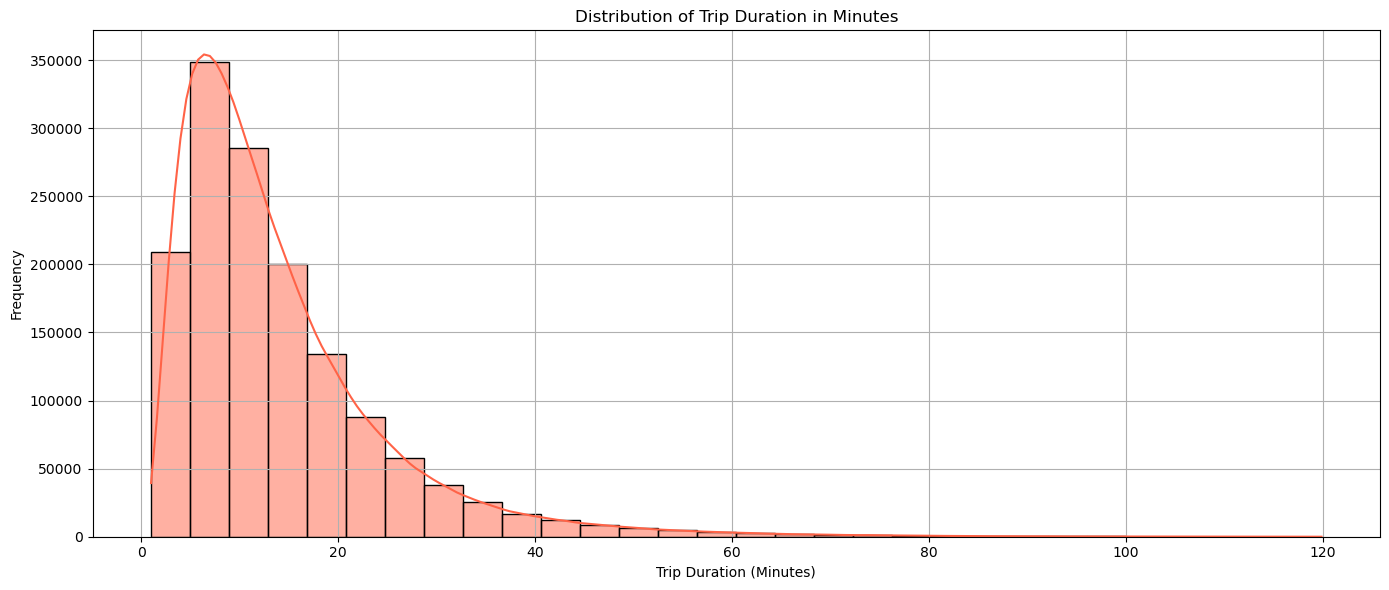

In [34]:
plt.figure(figsize=(14, 6)) # Set the figure size
sns.histplot(data=new_df, x='trip_duration_in_minutes', bins=30, kde=True, color="#FF6347") # Create a histogram with a kernel density estimate (KDE) overlay   
plt.title('Distribution of Trip Duration in Minutes') # Set the title of the plot
plt.xlabel('Trip Duration (Minutes)') # Set the x-axis label
plt.ylabel('Frequency') #  Set the y-axis label
plt.grid() # Add a grid for better readability
plt.tight_layout() # Adjust the layout to prevent overlap
plt.show()

#### Monthly Trend Bar

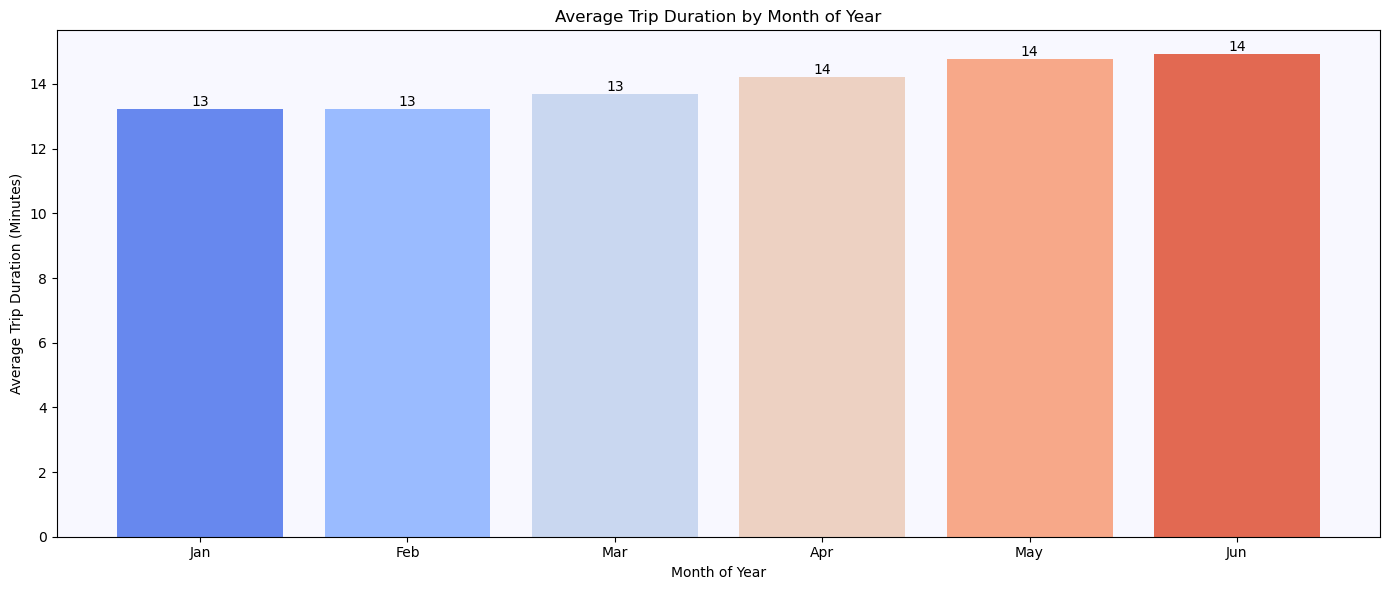

In [ ]:
monthly_duration = new_df.groupby('month_of_year')['trip_duration_in_minutes'].mean() # Calculate the average trip duration for each month of the year

fig, ax = plt.subplots(figsize=(14, 6)) # Create a bar plot for average trip duration by month of year with a color palette

ax.bar( #   
    monthly_duration.index,
    monthly_duration.values,
    color=sns.color_palette('coolwarm', len(monthly_duration.index))
)

for x in ax.patches:
    plt.annotate(
        str(int(x.get_height())),
        (x.get_x() + x.get_width() / 2, x.get_height()),
        ha='center',
        va='bottom'
    )

ax.set_facecolor('#F8F8FF')

ax.set_title('Average Trip Duration by Month of Year')
ax.set_xlabel('Month of Year')
ax.set_ylabel('Average Trip Duration (Minutes)')

ax.set_xticks(range(1, 7))
ax.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
)

plt.tight_layout()
plt.show()

#### *Heatmap (hour of days,days of week by trip count)*

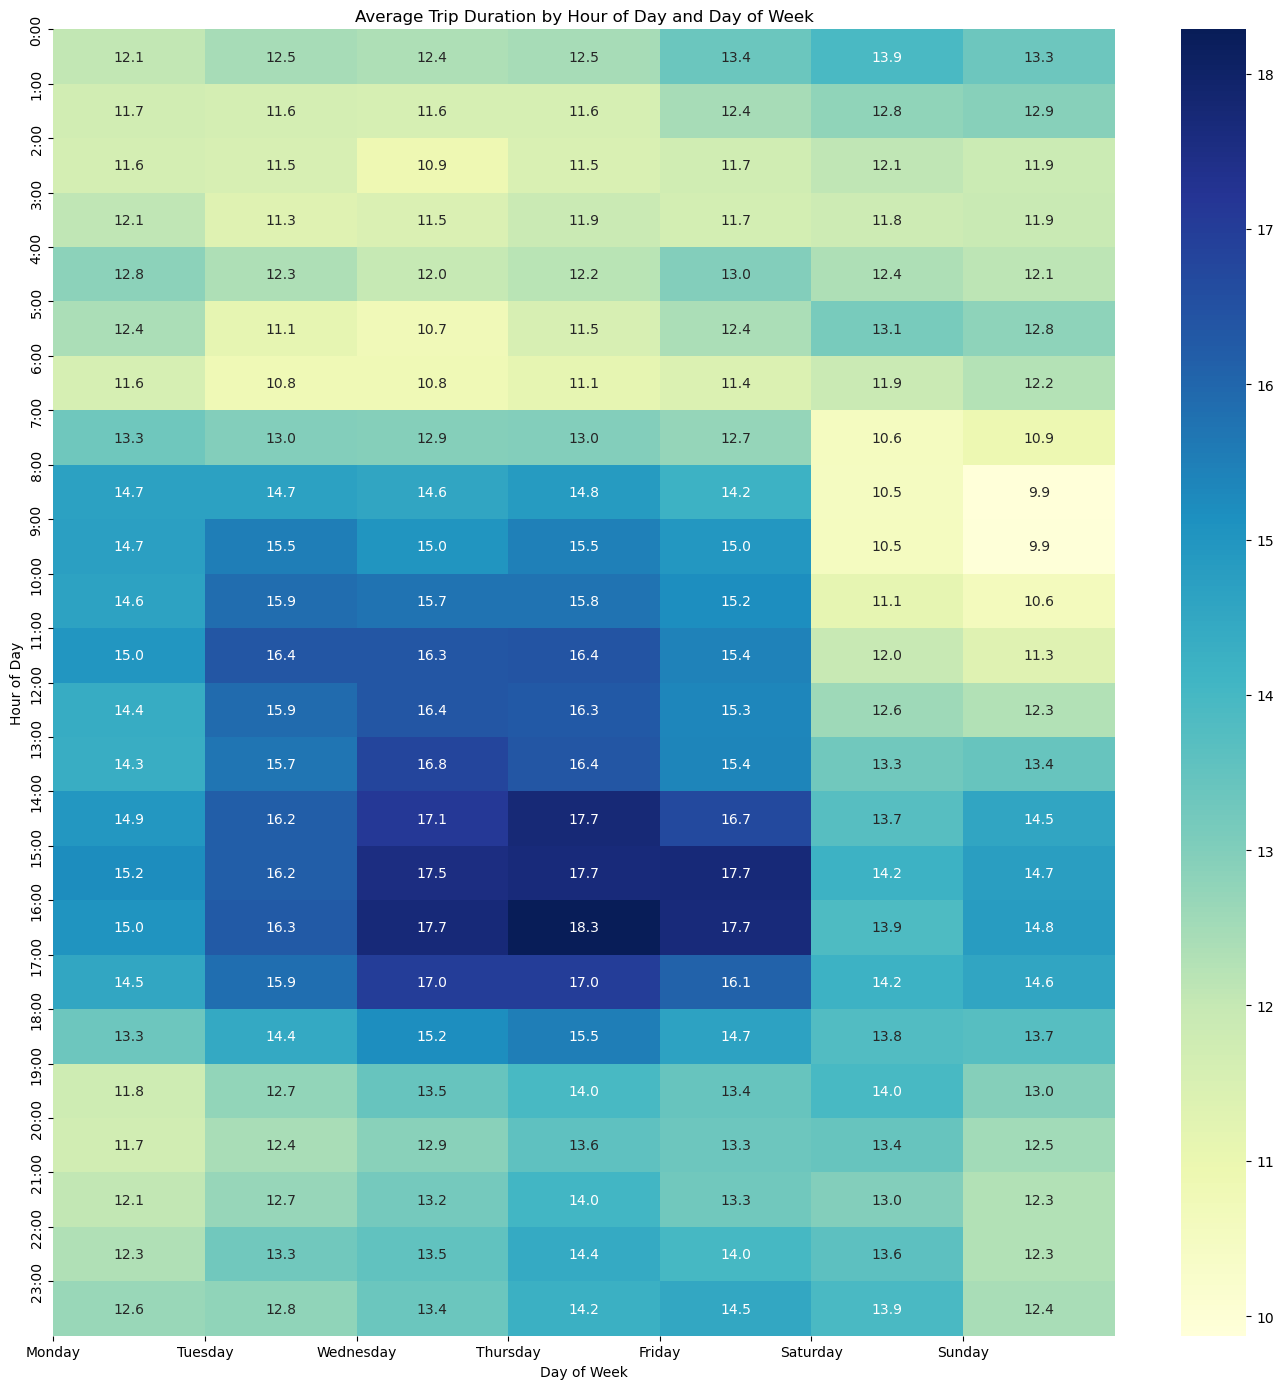

In [33]:
pivot = new_df.pivot_table(index='hour_of_day', columns='day_of_week', values='trip_duration_in_minutes', aggfunc='mean')
plt.figure(figsize=(14, 14))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Average Trip Duration by Hour of Day and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.xticks(ticks=range(0, 7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.yticks(ticks=range(0, 24), labels=[f'{h}:00' for h in range(0, 24)])
plt.tight_layout()
plt.show()

### Author: *Huseyn Ahmadov*

# <p align = center> *Thanks for your considerations*